# Gaussian Process Regression (GPR) & Physics-driven Computing

Gaussian Process Regression (GPR) is a non-parametric, Bayesian approach to regression. Unlike parametric models (like linear regression) where we find a distribution over parameters, a Gaussian Process defines a prior **distribution over functions**.

A Gaussian Process (GP) is completely defined by its mean function $m(x)$ and covariance function (or kernel) $k(x, x')$.

$$ f(x) \sim GP(m(x), k(x, x')) $$

Typically, we assume a prior mean of zero ($m(x) = 0$) for simplicity. The kernel $k(x, x')$ dictates the smoothness and shape of the functions. A common choice is the Squared Exponential (or Radial Basis Function) kernel.

### The Mathematical Formulation

Assume we have training inputs $X$ and target values $y$. We assume observations are noisy versions of the true function $f(x)$:

$$ y = f(x) + \epsilon, \quad \epsilon \sim N(0, \sigma_n^2) $$

If we want to make predictions $f_*$ at new test points $X_*$, the joint distribution of the training targets $y$ and the test outputs $f_*$ is a multivariate Gaussian:

$$ \begin{bmatrix} y \\ f_* \end{bmatrix} \sim N \left( \mathbf{0}, \begin{bmatrix} K(X, X) + \sigma_n^2 I & K(X, X_*) \\ K(X_*, X) & K(X_*, X_*) \end{bmatrix} \right) $$

Where:
* $K(X, X)$ is the covariance matrix evaluated between all training points.
* $K(X, X_*)$ is the covariance between training and test points.
* $K(X_*, X_*)$ is the covariance between test points.
* $\sigma_n^2 I$ adds the observation noise variance to the diagonal of the training covariance.

### Solving the GP (The Posterior)

To "solve" the GPR, we calculate the posterior distribution—the distribution of $f_*$ conditioned on the observed data $X, y$. Using the rules of conditioning for multivariate Gaussians, the predictive posterior distribution is also Gaussian:

$$ f_* | X, y, X_* \sim N(\mu_*, \Sigma_*) $$

With the predictive mean (our prediction) and predictive covariance (our uncertainty) given by:

1. **Predictive Mean:**
   $$ \mu_* = K(X_*, X) [K(X, X) + \sigma_n^2 I]^{-1} y $$
2. **Predictive Covariance (Uncertainty):**
   $$ \Sigma_* = K(X_*, X_*) - K(X_*, X) [K(X, X) + \sigma_n^2 I]^{-1} K(X, X_*) $$

### What We Need to Solve It

To actually compute these predictions in practice, we need:

1. **A Covariance Function (Kernel):** We must choose an appropriate kernel that reflects our prior beliefs about the data (e.g., periodic, linear, smooth). We will use the RBF kernel defined as:
   $$ k(x, x') = \sigma_f^2 \exp\left( -\frac{||x - x'||^2}{2l^2} \right) $$
2. **Hyperparameter Optimization:** Kernels have hyperparameters (like length-scale and variance). We find the best hyperparameters by maximizing the **Log Marginal Likelihood (LML)** of the observed data using gradient-based optimizers.
3. **Matrix Inversion:** The equations above require inverting $[K(X, X) + \sigma_n^2 I]$. Because matrix inversion is computationally expensive ($O(N^3)$ where $N$ is the number of training points) and prone to numerical instability, we typically use the **Cholesky decomposition** of the covariance matrix instead of direct inversion. The Cholesky decomposition factors our symmetric, positive-definite matrix into $L L^T$, where $L$ is a lower triangular matrix. This allows us to solve linear systems (like computing $[K + \sigma_n^2 I]^{-1} y$) using forward and backward substitution. While still $O(N^3)$ in overall complexity, it is significantly faster by a constant factor and far more numerically stable than computing the direct inverse.

# Thermodynamic Linear Algebra by Aifer, et.al

The paper proposes a novel, physics-based computing paradigm to accelerate linear algebra operations by leveraging classical thermodynamics. Standard digital methods (like LU decomposition) are computationally expensive for large matrices. To bridge this gap, the authors map fundamental linear algebra problems—like solving linear systems ($Ax = b$), computing matrix inverses, and finding determinants—to the physical dynamics of coupled harmonic oscillators. By letting an analog, stochastic hardware system reach thermodynamic equilibrium, these mathematical solutions can be naturally sampled, theoretically achieving speedups that scale linearly with the matrix dimension.

**Mean, Variance, and the Matrix Inverse**

In the thermodynamic framework described by the paper, a matrix $A$ defines the coupling (or potential energy landscape) of a system of harmonic oscillators. The energy of the system is given by

$$U(x) = \frac{1}{2}x^T Ax + bx.$$

If you apply a constant external force $\mathbf{b}$ to the oscillators, the system will eventually settle into a thermal equilibrium. The mean position (average state) of the oscillators in this equilibrium state naturally corresponds to the solution of the linear system. Therefore, the mean
$$\langle \mathbf{x} \rangle = A^{-1}\mathbf{b}.$$

Even at equilibrium, the oscillators experience random thermal fluctuations. The covariance (or variance) matrix of these fluctuations around the mean is directly proportional to the inverse of the matrix $A$. Mathematically, the covariance matrix

$$\Sigma = k_B T A^{-1}.$$

In short: You can solve a linear system by measuring the mean state of the analog thermodynamic system, and you can compute the matrix inverse by measuring the variance (covariance) of its thermal fluctuations over time.


Thus when such a system of oscillators with a quadratic potential energy function $U(x)$ is allowed to equilibrate with its environment at an inverse temperature $\beta = 1/k_B T$, the equilibrium state corresponds to a multivariate Gaussian distribution:

$$x \sim {N}[A^{-1}b, \beta^{-1}A^{-1}].$$

### Implementing GPR with Thermodynamic Linear Algebra (TLA)

The following code demonstrates how to apply the principles of Thermodynamic Linear Algebra to solve Gaussian Process Regression. Instead of using traditional, computationally heavy digital algorithms (like Cholesky decomposition or direct matrix inversion) to solve the linear systems required for GPR, we simulate a physical relaxation process.

**What the code is doing:**
1. **Overdamped Langevin Dynamics:** The `tla_solve` function simulates a physical system of coupled harmonic oscillators reaching thermal equilibrium. The interactions between the oscillators are governed by our GPR covariance matrix ($K_y$).
2. **Solving for the Mean:** To compute the predictive mean, we need the weight vector $\alpha = K_y^{-1}y$. In the TLA paradigm, we apply a "force" proportional to our training targets $y$. The system relaxes, and the *mean position* of the oscillators converges to our solution $\alpha$.
3. **Solving for the Variance:** To find the uncertainty at a new test point, we solve $K_y v = k_*$ (the covariance between training points and the test point). We use the same thermodynamic relaxation approach—applying $k_*$ as a pseudo-force—to find $v$ without directly inverting the matrix. Note that for the RBF kernel - K(X_*, X_*) = I.

**TLA to GPR Mapping:**

From above we know that -

1. **Predictive Mean:**
   $$ \mu_* = K(X_*, X) [K(X, X) + \sigma_n^2 I]^{-1} y $$
2. **Predictive Covariance (Uncertainty):**
   $$ \Sigma_* = K(X_*, X_*) - K(X_*, X) [K(X, X) + \sigma_n^2 I]^{-1} K(X, X_*) $$

| TLA Physical System | Mathematical Equivalent ($Ax = b$) | GPR Implementation |
| :--- | :--- | :--- |
| Oscillator Coupling Matrix ($A$) | $A$ | Noisy Training Covariance ($K_y = K(X, X) + \sigma_n^2 I$) |
| External Force ($b$) for Mean | $b$ | Training Targets ($y$) |
| Equilibrium State ($\langle x \rangle$) | $x = A^{-1}b$ | Predictive Weights ($\alpha = K_y^{-1}y$) |
| Pseudo-Force ($b$) for Variance | $b$ | Test-Train Covariance ($k_* = K(X_*, X)$) |
| Equilibrium State ($\langle v \rangle$) | $v = A^{-1}b$ | Variance Reduction Vector ($v = K_y^{-1}k_*$) |
| Thermal Fluctuations Variance | $\Sigma \propto A^{-1}$ | Inverse Covariance ($K_y^{-1}$) |

**Computational Complexity:**
*   **Standard GPR:** Finding the exact predictive mean and variance requires inverting the $N \times N$ training covariance matrix. This scales as **$O(N^3)$** in time, which becomes a severe bottleneck for large datasets.
*   **TLA Approach:** The promise of TLA is realized when run on **analog thermodynamic hardware**. Instead of $O(N^3)$ sequential operations, the physical system naturally equilibrates. Under reasonable assumptions about the condition number of the matrix, the physical relaxation time scales linearly (**$O(N)$**) or even independently of the matrix dimension, offering massive theoretical speedups.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- CORE FUNCTIONS ---

def rbf_kernel(x1, x2, l=0.5):
    """Computes the RBF covariance matrix."""
    sqdist = np.subtract.outer(x1, x2)**2
    return np.exp(-0.5 * sqdist / l**2)

def tla_solve(A, b, dt=0.005, steps=5000, burn_in=1000):
    """
    Simulates TLA Linear System Protocol (Section II.B).
    Solves Ax = b by simulating physical relaxation.
    """
    d = A.shape[0]
    x = np.zeros(d)
    gamma = 1.0     # Damping constant [cite: 447]
    beta_inv = 0.005 # Simulated temperature (k_B * T)

    samples = []
    for i in range(steps):
        # Overdamped Langevin (ODL) equation [cite: 445]
        # dx = -1/gamma * (Ax - b)dt + sqrt(2*dt*beta_inv/gamma) * N(0,1)
        drift = -(1/gamma) * (A @ x - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x += drift + noise

        # Ergodic time-averaging starts after equilibration time t0 [cite: 116]
        if i > burn_in:
            samples.append(x.copy())

    return np.mean(samples, axis=0)

# --- 1. DATA GENERATION ---

np.random.seed(42)
n_train = 100
X_train = np.sort(np.random.uniform(-4, 4, n_train))
Y_train = np.sin(X_train) + np.random.normal(0, 0.1, n_train)

X_test = np.linspace(-5, 5, 50)
l, sigma_n2 = 0.7, 0.1

# Precompute the Training Covariance (Encoded into 'Hardware' Topology)
K_train = rbf_kernel(X_train, X_train, l)
Ky = K_train + sigma_n2 * np.eye(n_train)

# --- 2. GPR INFERENCE (Numerical vs TLA) ---

# Solve for weights alpha (Mean computation)
alpha_num = np.linalg.solve(Ky, Y_train)
alpha_tla = tla_solve(Ky, Y_train)

mu_num, var_num = [], []
mu_tla, var_tla = [], []

print("Running Thermodynamic Inference...")
for xt in X_test:
    k_star = rbf_kernel(np.array([xt]), X_train, l).flatten()

    # Standard Numerical Benchmark
    mu_num.append(k_star @ alpha_num)
    v_num = np.linalg.solve(Ky, k_star)
    var_num.append(1.0 - k_star @ v_num)

    # TLA Approach
    # Mean is a cheap dot product once alpha is found via relaxation
    mu_tla.append(k_star @ alpha_tla)

    # Variance via 'Pseudo-Force' Method: Solve Ky * v = k_star
    v_tla = tla_solve(Ky, k_star)
    var_tla.append(1.0 - k_star @ v_tla)

# Convert to arrays for Plotly and ensure variance is strictly non-negative
mu_num, var_num = np.array(mu_num), np.maximum(np.array(var_num), 0)
mu_tla, var_tla = np.array(mu_tla), np.maximum(np.array(var_tla), 0)

# --- 3. INTERACTIVE VISUALIZATION ---

fig = go.Figure()

# Training Data
fig.add_trace(go.Scatter(x=X_train, y=Y_train, mode='markers',
                         name='Training Data', marker=dict(color='black', size=6)))

# Numerical GPR Mean & CI
fig.add_trace(go.Scatter(x=X_test, y=mu_num, mode='lines',
                         name='Numerical Mean', line=dict(color='red', dash='dash')))
fig.add_trace(go.Scatter(x=np.concatenate([X_test, X_test[::-1]]),
                         y=np.concatenate([mu_num - 2*np.sqrt(var_num), (mu_num + 2*np.sqrt(var_num))[::-1]]),
                         fill='toself', fillcolor='rgba(255,0,0,0.1)', line=dict(color='rgba(255,255,255,0)'),
                         hoverinfo="skip", showlegend=True, name='Numerical 95% CI'))

# TLA GPR Mean & CI
fig.add_trace(go.Scatter(x=X_test, y=mu_tla, mode='lines',
                         name='Thermodynamic Mean (TLA)', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=np.concatenate([X_test, X_test[::-1]]),
                         y=np.concatenate([mu_tla - 2*np.sqrt(var_tla), (mu_tla + 2*np.sqrt(var_tla))[::-1]]),
                         fill='toself', fillcolor='rgba(0,0,255,0.2)', line=dict(color='rgba(255,255,255,0)'),
                         hoverinfo="skip", showlegend=True, name='TLA 95% CI'))

fig.update_layout(title="Scaling GPR: Numerical vs. Thermodynamic Linear Algebra",
                  xaxis_title="Input (X)", yaxis_title="Predicted (Y)",
                  template="plotly_white", legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01))

fig.show()


Running Thermodynamic Inference...


**Van der Pol ODE solve using TLA**

The van der Pol oscillator is a non-conservative oscillator with non-linear damping. It evolves in time according to the second-order differential equation:

$$ \frac{d^2x}{dt^2} - \mu(1-x^2)\frac{dx}{dt} + x = 0 $$

To solve this numerically (and to model it with our GPR), we write it as a system of two first-order ODEs by letting $y = \frac{dx}{dt}$:

$$ \frac{dx}{dt} = y $$
$$ \frac{dy}{dt} = \mu(1-x^2)y - x $$

Here, $\mu$ is a scalar parameter that controls the nonlinearity and the strength of the damping.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- 1. VAN DER POL ODE & KERNEL ---
def vdp_ode(z, t, mu=1.5):
    x, y = z
    return np.array([y, mu * (1 - x**2) * y - x])

def rbf_kernel(t1, t2, l=1.0):
    return np.exp(-0.5 * (np.subtract.outer(t1, t2)**2) / l**2)

# --- 2. STABLE TLA SOLVER (ODL Dynamics) ---
def tla_solve(A, b, steps=250, burn_in=50):  ## play around with steps & burn_in
    """Based on TLA Paper: Eq. 27 & Linear System Protocol"""
    d = A.shape[0]
    # Stability: dt < 2/max_eigenvalue [cite: 448]
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.35 / matrix_norm

    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0005 # Lower temperature for higher precision

    samples = []
    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise

        if i > burn_in:
            samples.append(x_state.copy()) # Ergodic averaging [cite: 114]

    return np.mean(samples, axis=0)

# --- 3. DATA GENERATION ---
np.random.seed(42)
t_train = np.sort(np.random.uniform(0, 15, 60))
z_obs, dot_z_obs = [], []
curr_z = np.array([1.0, 0.0])

for t in t_train:
    dot_z = vdp_ode(curr_z, t)
    z_obs.append(curr_z.copy())
    dot_z_obs.append(dot_z + np.random.normal(0, 0.05, 2))
    curr_z += dot_z * 0.1

z_obs, dot_z_obs = np.array(z_obs), np.array(dot_z_obs)

# --- 4. FULL GPR INFERENCE ---
l, sigma_n2 = 1.2, 0.05
K_full = rbf_kernel(t_train, t_train, l)
Ky = K_full + sigma_n2 * np.eye(len(t_train))

# Solving for weights alpha using Thermodynamic Relaxation [cite: 92]
print("TLA Solver: Relaxing Full Oscillator Network...")
alpha_x_tla = tla_solve(Ky, dot_z_obs[:, 0])
alpha_y_tla = tla_solve(Ky, dot_z_obs[:, 1])

# --- 5. NUMERICAL BENCHMARK ---
alpha_x_num = np.linalg.solve(Ky, dot_z_obs[:, 0])
alpha_y_num = np.linalg.solve(Ky, dot_z_obs[:, 1])

# --- 6. INTEGRATE FORWARD ---
t_test = np.linspace(0, 15, 120)
z_tla, z_num = [np.array([1.0, 0.0])], [np.array([1.0, 0.0])]

for i in range(len(t_test)-1):
    ks = rbf_kernel(np.array([t_test[i]]), t_train, l).flatten()

    # TLA Trajectory
    dt_int = t_test[1] - t_test[0]
    z_tla.append(z_tla[-1] + np.array([ks @ alpha_x_tla, ks @ alpha_y_tla]) * dt_int)

    # Numerical Trajectory
    z_num.append(z_num[-1] + np.array([ks @ alpha_x_num, ks @ alpha_y_num]) * dt_int)

z_tla, z_num = np.array(z_tla), np.array(z_num)

# --- 7. VISUALIZE COMPARISON ---
fig = go.Figure()
fig.add_trace(go.Scatter(x=z_obs[:,0], y=z_obs[:,1], mode='markers', name='Noisy Observations', marker=dict(color='black', size=4)))
fig.add_trace(go.Scatter(x=z_num[:,0], y=z_num[:,1], mode='lines', name='Numerical GPR-ODE', line=dict(color='red', dash='dot')))
fig.add_trace(go.Scatter(x=z_tla[:,0], y=z_tla[:,1], mode='lines', name='Full TLA GPR-ODE', line=dict(color='blue', width=3)))

fig.update_layout(title="Full GPR-ODE: Thermodynamic Relaxation vs. Digital SOTA",
                  xaxis_title="X State", yaxis_title="Y State", template="plotly_white")
fig.show()


TLA Solver: Relaxing Full Oscillator Network...


## **Converting from learning positions to learning velocities**

Note: Cheated here to calculate velocities, since we knew the ODE already

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from scipy.spatial.distance import cdist

# --- 1. VAN DER POL ODE & 2D KERNEL ---
def vdp_ode(t, z, mu=1.5):
    """Van der Pol oscillator (Autonomous, so velocity only depends on z)"""
    x, y = z
    return np.array([y, mu * (1 - x**2) * y - x])

def rbf_kernel_2d(Z1, Z2, l=1.0):
    """Computes RBF Kernel between 2D state vectors."""
    # cdist computes the squared euclidean distance between all pairs
    sq_dist = cdist(Z1, Z2, 'sqeuclidean')
    return np.exp(-0.5 * sq_dist / l**2)

# --- 2. STABLE TLA SOLVER (ODL Dynamics) ---
def tla_solve(A, b, steps=300, burn_in=100):
    """Based on TLA Paper: Eq. 27 & Linear System Protocol"""
    d = A.shape[0]
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.35 / matrix_norm

    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0005

    samples = []
    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise

        if i > burn_in:
            samples.append(x_state.copy())

    return np.mean(samples, axis=0)

# --- 3. DATA GENERATION (Fixed) ---
np.random.seed(42)
t_span = (0, 15)
t_train = np.sort(np.random.uniform(t_span[0], t_span[1], 60))
z0 = np.array([1.0, 0.0])

# Use solve_ivp to generate accurate ground truth states
sol = solve_ivp(vdp_ode, t_span, z0, t_eval=t_train, rtol=1e-8, atol=1e-8)
z_obs = sol.y.T  # Shape: (60, 2)

# Calculate observed velocities (with a little noise)
dot_z_obs = np.array([vdp_ode(0, z) for z in z_obs])
dot_z_obs += np.random.normal(0, 0.05, dot_z_obs.shape)

# --- 4. FULL GPR INFERENCE (Learning the Vector Field) ---
l, sigma_n2 = 1.2, 0.05

# Kernel is now built on the STATES (z_obs), not time (t_train)
K_full = rbf_kernel_2d(z_obs, z_obs, l)
Ky = K_full + sigma_n2 * np.eye(len(t_train))

print("Solving Numerical GPR...")
alpha_x_num = np.linalg.solve(Ky, dot_z_obs[:, 0])
alpha_y_num = np.linalg.solve(Ky, dot_z_obs[:, 1])

print("TLA Solver: Relaxing Full Oscillator Network...")
alpha_x_tla = tla_solve(Ky, dot_z_obs[:, 0])
alpha_y_tla = tla_solve(Ky, dot_z_obs[:, 1])

# --- 5. CLOSED-LOOP INTEGRATION ---
# We define a function that the integrator can call at any arbitrary state
def gp_vector_field(t, z, alphas_x, alphas_y, Z_train, length_scale):
    """Predicts velocity purely based on current state z."""
    z = z.reshape(1, 2)
    ks = rbf_kernel_2d(z, Z_train, length_scale).flatten()

    pred_dot_x = ks @ alphas_x
    pred_dot_y = ks @ alphas_y
    return np.array([pred_dot_x, pred_dot_y])

# Time vector for smooth plotting
t_test = np.linspace(t_span[0], t_span[1], 200)

print("Integrating Learned GPR-ODE (Numerical Weights)...")
sol_num = solve_ivp(
    lambda t, z: gp_vector_field(t, z, alpha_x_num, alpha_y_num, z_obs, l),
    t_span, z0, t_eval=t_test, rtol=1e-6, atol=1e-6
)

print("Integrating Learned GPR-ODE (TLA Weights)...")
sol_tla = solve_ivp(
    lambda t, z: gp_vector_field(t, z, alpha_x_tla, alpha_y_tla, z_obs, l),
    t_span, z0, t_eval=t_test, rtol=1e-6, atol=1e-6
)

z_num = sol_num.y.T
z_tla = sol_tla.y.T

# --- 6. VISUALIZE COMPARISON ---
fig = go.Figure()

# Plot the training observations
fig.add_trace(go.Scatter(x=z_obs[:,0], y=z_obs[:,1], mode='markers',
                         name='Noisy State Observations', marker=dict(color='black', size=6)))

# Plot the Numerical GPR Trajectory
fig.add_trace(go.Scatter(x=z_num[:,0], y=z_num[:,1], mode='lines',
                         name='Numerical GPR-ODE Vector Field', line=dict(color='red', dash='dot', width=2)))

# Plot the TLA GPR Trajectory
fig.add_trace(go.Scatter(x=z_tla[:,0], y=z_tla[:,1], mode='lines',
                         name='TLA GPR-ODE Vector Field', line=dict(color='blue', width=2)))

fig.update_layout(
    title="Closed-Loop GPR-ODE: Learning the Vector Field (TLA vs Digital)",
    xaxis_title="X State",
    yaxis_title="Y State",
    template="plotly_white",
    width=800, height=600
)

fig.show()

Solving Numerical GPR...
TLA Solver: Relaxing Full Oscillator Network...
Integrating Learned GPR-ODE (Numerical Weights)...
Integrating Learned GPR-ODE (TLA Weights)...


### **Noise parameter variaition**

In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- 1. VAN DER POL ODE & KERNEL ---
def vdp_ode(z, t, mu=1.5):
    x, y = z
    return np.array([y, mu * (1 - x**2) * y - x])

def rbf_kernel(t1, t2, l=1.0):
    return np.exp(-0.5 * (np.subtract.outer(t1, t2)**2) / l**2)

# --- 2. STABLE TLA SOLVER (ODL Dynamics) ---
def tla_solve(A, b, beta_inv, steps=250, burn_in=50):  ## play around with steps & burn_in
    """Based on TLA Paper: Eq. 27 & Linear System Protocol"""
    d = A.shape[0]
    # Stability: dt < 2/max_eigenvalue [cite: 448]
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.35 / matrix_norm

    x_state = np.zeros(d)
    gamma = 1.0 # Lower temperature for higher precision

    samples = []
    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise

        if i > burn_in:
            samples.append(x_state.copy()) # Ergodic averaging [cite: 114]

    return np.mean(samples, axis=0)

# --- 3. DATA GENERATION ---
np.random.seed(42)
t_train = np.sort(np.random.uniform(0, 15, 60))
z_obs, dot_z_obs = [], []
curr_z = np.array([1.0, 0.0])

for t in t_train:
    dot_z = vdp_ode(curr_z, t)
    z_obs.append(curr_z.copy())
    dot_z_obs.append(dot_z + np.random.normal(0, 0.05, 2))
    curr_z += dot_z * 0.1

z_obs, dot_z_obs = np.array(z_obs), np.array(dot_z_obs)

# --- 4. FULL GPR INFERENCE ---
l, sigma_n2 = 1.2, 0.05
K_full = rbf_kernel(t_train, t_train, l)
Ky = K_full + sigma_n2 * np.eye(len(t_train))
beta_inv_list = [0.000001, 0.00001, 0.0005, 0.005, 0.05]

for beta_inv in beta_inv_list:
  # Solving for weights alpha using Thermodynamic Relaxation [cite: 92]
  print("TLA Solver: Relaxing Full Oscillator Network...")
  alpha_x_tla = tla_solve(Ky, dot_z_obs[:, 0], beta_inv = beta_inv)
  alpha_y_tla = tla_solve(Ky, dot_z_obs[:, 1], beta_inv = beta_inv)

  # --- 5. NUMERICAL BENCHMARK ---
  alpha_x_num = np.linalg.solve(Ky, dot_z_obs[:, 0])
  alpha_y_num = np.linalg.solve(Ky, dot_z_obs[:, 1])

  # --- 6. INTEGRATE FORWARD ---
  t_test = np.linspace(0, 15, 120)
  z_tla, z_num = [np.array([1.0, 0.0])], [np.array([1.0, 0.0])]

  for i in range(len(t_test)-1):
      ks = rbf_kernel(np.array([t_test[i]]), t_train, l).flatten()

      # TLA Trajectory
      dt_int = t_test[1] - t_test[0]
      z_tla.append(z_tla[-1] + np.array([ks @ alpha_x_tla, ks @ alpha_y_tla]) * dt_int)

      # Numerical Trajectory
      z_num.append(z_num[-1] + np.array([ks @ alpha_x_num, ks @ alpha_y_num]) * dt_int)

  z_tla, z_num = np.array(z_tla), np.array(z_num)

  # --- 7. VISUALIZE COMPARISON ---
  fig = go.Figure()
  fig.add_trace(go.Scatter(x=z_obs[:,0], y=z_obs[:,1], mode='markers', name='Noisy Observations', marker=dict(color='black', size=4)))
  fig.add_trace(go.Scatter(x=z_num[:,0], y=z_num[:,1], mode='lines', name='Numerical GPR-ODE', line=dict(color='red', dash='dot')))
  fig.add_trace(go.Scatter(x=z_tla[:,0], y=z_tla[:,1], mode='lines', name='Full TLA GPR-ODE', line=dict(color='blue', width=3)))

  fig.update_layout(title=f"Full GPR-ODE: Thermodynamic Relaxation vs. Digital for {beta_inv}",
                    xaxis_title="X State", yaxis_title="Y State", template="plotly_white")
  fig.show()

TLA Solver: Relaxing Full Oscillator Network...


TLA Solver: Relaxing Full Oscillator Network...


TLA Solver: Relaxing Full Oscillator Network...


TLA Solver: Relaxing Full Oscillator Network...


TLA Solver: Relaxing Full Oscillator Network...


## **Lorentz attractor solve using TLA**

The Lorenz system is a system of ordinary differential equations notable for exhibiting chaotic behavior for certain parameter values and initial conditions. The equations describe the rate of change of three quantities with respect to time:

$$ \frac{dx}{dt} = \sigma(y - x) $$
$$ \frac{dy}{dt} = x(\rho - z) - y $$
$$ \frac{dz}{dt} = xy - \beta z $$

Where:
* **$\sigma$** is the Prandtl number.
* **$\rho$** is the Rayleigh number.
* **$\beta$** is a geometric factor.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- 1. LORENZ ATTRACTOR DYNAMICS ---
def lorenz_ode(state, t, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z])

def rbf_kernel(t1, t2, l=1.5):
    return np.exp(-0.5 * (np.subtract.outer(t1, t2)**2) / l**2)

# --- 2. STABLE TLA SOLVER (Linear Scaling O(d)) ---
def tla_solve(A, b, steps=10000, burn_in=2000):
    """
    Physical relaxation to find alpha = A^-1 * b.
    Citations: Linear System Protocol [cite: 167-186]
    """
    d = A.shape[0]
    ## for numerical stability in Euler-Maruyama dt < 2/max_eigenvalue
    ## for SPD, max_eig = 2-norm
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.3 / matrix_norm # Stability factor

    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0001 # Lower temperature = higher precision [cite: 388]

    samples = []
    for i in range(steps):
        # Force/Pull balance: drift = -1/gamma * (Ax - b) [cite: 445]
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise

        # Ergodic integration [cite: 113-117]
        if i > burn_in:
            samples.append(x_state.copy())

    return np.mean(samples, axis=0)

# --- 3. DATA GENERATION (SCALING UP TO 250 POINTS) ---
np.random.seed(42)
n_train = 250
t_train = np.sort(np.random.uniform(0, 10, n_train))
z_obs, dot_z_obs = [], []
curr_z = np.array([1.0, 1.0, 1.0])

for t in t_train:
    dot_z = lorenz_ode(curr_z, t)
    z_obs.append(curr_z.copy())
    dot_z_obs.append(dot_z + np.random.normal(0, 0.1, 3)) # Noisy sensors
    curr_z += dot_z * 0.01

z_obs, dot_z_obs = np.array(z_obs), np.array(dot_z_obs)

# GPR Setup
l, sigma_n2 = 1.5, 0.05
K_full = rbf_kernel(t_train, t_train, l)
Ky = K_full + sigma_n2 * np.eye(n_train) # Matrix A [cite: 96]

# --- 4. TLA RELAXATION FOR 3D VECTOR FIELD ---
print(f"Relaxing {n_train}-node oscillator network for Lorenz Attractor...")
alpha_x = tla_solve(Ky, dot_z_obs[:, 0])
alpha_y = tla_solve(Ky, dot_z_obs[:, 1])
alpha_z = tla_solve(Ky, dot_z_obs[:, 2])

# --- 5. INTEGRATE CHAOTIC TRAJECTORY ---
t_test = np.linspace(0, 10, 500)
dt_int = t_test[1] - t_test[0]
z_tla = [np.array([1.0, 1.0, 1.0])]

for i in range(len(t_test)-1):
    ks = rbf_kernel(np.array([t_test[i]]), t_train, l).flatten()
    # Predict 3D Velocity
    v_field = np.array([ks @ alpha_x, ks @ alpha_y, ks @ alpha_z])
    z_tla.append(z_tla[-1] + v_field * dt_int)

z_tla = np.array(z_tla)

# --- 6. 3D VISUALIZATION ---
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=z_obs[:,0], y=z_obs[:,1], z=z_obs[:,2],
                           mode='markers', marker=dict(size=2, color='black'), name='Noisy Observations'))
fig.add_trace(go.Scatter3d(x=z_tla[:,0], y=z_tla[:,1], z=z_tla[:,2],
                           mode='lines', line=dict(color='blue', width=4), name='TLA GPR-ODE (Butterfly)'))

fig.update_layout(title="Chaos via Thermodynamic Relaxation: Lorenz Attractor GPR-ODE",
                  scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
                  template="plotly_white")
fig.show()

Relaxing 250-node oscillator network for Lorenz Attractor...


Same issue as with the Van der Pol case where we need the turn it into a GPR of the velocity from state. This code too is cheating in how velocity was calculated - need to find better solutions for this.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from scipy.spatial.distance import cdist

# --- 1. LORENZ ATTRACTOR DYNAMICS & 3D KERNEL ---
def lorenz_ode(t, state, sigma=10, rho=28, beta=8/3):
    """The rules of the universe (used here to generate exact targets)"""
    x, y, z = state
    return np.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z])

def rbf_kernel_nd(Z1, Z2, l=15.0):
    """State-Space RBF Kernel"""
    sq_dist = cdist(Z1, Z2, 'sqeuclidean')
    return np.exp(-0.5 * sq_dist / l**2)

# --- 2. STABLE TLA SOLVER ---
def tla_solve(A, b, steps=10000, burn_in=2000):
    """Thermodynamic relaxation solver"""
    d = A.shape[0]
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.3 / matrix_norm

    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0001

    samples = []
    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise
        if i > burn_in:
            samples.append(x_state.copy())

    return np.mean(samples, axis=0)

# --- 3. DATA GENERATION ---
np.random.seed(42)
n_train = 250
t_span = (0, 10)
# Randomly spaced timestamps
t_train = np.sort(np.random.uniform(t_span[0], t_span[1], n_train))
z0 = np.array([1.0, 1.0, 1.0])

# Generate accurate ground truth states using the ODE
sol = solve_ivp(lorenz_ode, t_span, z0, t_eval=t_train, rtol=1e-8, atol=1e-8)
z_obs = sol.y.T  # Shape: (250, 3)

# --- 4. THE CHEAT: PERFECT VELOCITY TARGETS ---
print("Generating 'Cheat' Velocities from Exact ODE...")
# We ask the exact ODE: "If you are at this specific z_obs, what is your exact velocity?"
dot_z_obs = np.array([lorenz_ode(0, z) for z in z_obs])

# We add a tiny bit of noise just to simulate standard sensor imperfection
dot_z_obs += np.random.normal(0, 0.1, dot_z_obs.shape)

# --- 5. FULL GPR INFERENCE (Numerical vs TLA) ---
l_state, sigma_n2 = 15.0, 0.05

# Kernel trained purely on Physical State Space
K_full = rbf_kernel_nd(z_obs, z_obs, l_state)
Ky = K_full + sigma_n2 * np.eye(n_train)

print("Solving Numerical GPR (Digital SOTA)...")
alpha_x_num = np.linalg.solve(Ky, dot_z_obs[:, 0])
alpha_y_num = np.linalg.solve(Ky, dot_z_obs[:, 1])
alpha_z_num = np.linalg.solve(Ky, dot_z_obs[:, 2])

print(f"Relaxing {n_train}-node oscillator network for Lorenz Attractor (TLA)...")
alpha_x_tla = tla_solve(Ky, dot_z_obs[:, 0])
alpha_y_tla = tla_solve(Ky, dot_z_obs[:, 1])
alpha_z_tla = tla_solve(Ky, dot_z_obs[:, 2])

# --- 6. INTEGRATE CHAOTIC TRAJECTORY ---
def gp_vector_field_3d(t, z, a_x, a_y, a_z, Z_train, length_scale):
    """Given a 3D state, predict the 3D velocity using GP weights"""
    z = z.reshape(1, 3)
    ks = rbf_kernel_nd(z, Z_train, length_scale).flatten()
    return np.array([ks @ a_x, ks @ a_y, ks @ a_z])

t_test = np.linspace(t_span[0], t_span[1], 1000)

print("Integrating Learned Numerical GPR-ODE...")
sol_num = solve_ivp(
    lambda t, z: gp_vector_field_3d(t, z, alpha_x_num, alpha_y_num, alpha_z_num, z_obs, l_state),
    t_span, z0, t_eval=t_test, rtol=1e-6, atol=1e-6
)

print("Integrating Learned TLA GPR-ODE...")
sol_tla = solve_ivp(
    lambda t, z: gp_vector_field_3d(t, z, alpha_x_tla, alpha_y_tla, alpha_z_tla, z_obs, l_state),
    t_span, z0, t_eval=t_test, rtol=1e-6, atol=1e-6
)

z_num = sol_num.y.T
z_tla = sol_tla.y.T

# --- 7. 3D VISUALIZATION ---
fig = go.Figure()

# Plot the 250 Observation Points
fig.add_trace(go.Scatter3d(x=z_obs[:,0], y=z_obs[:,1], z=z_obs[:,2],
                           mode='markers', marker=dict(size=3, color='black', opacity=0.8),
                           name='State Observations'))

# Plot Numerical GPR Trajectory
fig.add_trace(go.Scatter3d(x=z_num[:,0], y=z_num[:,1], z=z_num[:,2],
                           mode='lines', line=dict(color='red', width=3, dash='dash'),
                           name='Numerical GPR (Cheat Vels)'))

# Plot TLA GPR Trajectory
fig.add_trace(go.Scatter3d(x=z_tla[:,0], y=z_tla[:,1], z=z_tla[:,2],
                           mode='lines', line=dict(color='blue', width=4),
                           name='TLA GPR (Cheat Vels)'))

fig.update_layout(title="Lorenz Attractor Vector Field: GPR via Exact Velocity Targets",
                  scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
                  template="plotly_white",
                  margin=dict(l=0, r=0, b=0, t=40))
fig.show()

Generating 'Cheat' Velocities from Exact ODE...
Solving Numerical GPR (Digital SOTA)...
Relaxing 250-node oscillator network for Lorenz Attractor (TLA)...
Integrating Learned Numerical GPR-ODE...
Integrating Learned TLA GPR-ODE...


# **Sparse Variational GPR**

While standard Gaussian Process Regression (GPR) is a powerful technique that provides both predictions and well-calibrated uncertainty estimates - it has a fatal flaw when scaling to large datasets: computational complexity.

As we saw above, to compute the predictive mean and variance, we must invert the $N \times N$ training covariance matrix $(K + \sigma_n^2 I)$. Matrix inversion, even with Chloesky scales as **$O(N^3)$** in time where $N$ is the number of training data points. This means standard GPR becomes computationally intractable for datasets larger than a few thousand points.

The TLA approach above does enable us to solve this matrix inversion much faster, but we would still need a *NxN* covariance matrix realized in hardware. We would like to use TLA-inspired approach to solve this problem, but also not need all of the *N* training points to do it. Let us start by examining how this problem is solved using variational approaches.

**Sparse Variational GPR (SVGPR)**

SVGPR address the fundamental scaling bottleneck of GPR: training requires inverting an $N \times N$ covariance matrix, a process that scales with $O(N^3)$ complexity. For modern datasets where $N$ reaches into the thousands or millions, standard GPs become computationally intractable. SVGPR solves this by reframing the inference problem as an optimization problem through two key innovations: the use of Inducing Variables and the Variational Principle.

1. **Inducing Variables**: Instead of allowing every data point to exert a direct influence on the global covariance, we introduce a set of $M$ "inducing points" at locations $Z$. These act as a sparse set of landmarks that summarize the information contained in the full dataset. Mathematically, we assume the function is "anchored" by a set of variables $u = f(Z)$. The relationship between these anchors defines the global shape of the function. By choosing $M \ll N$, we reduce the dimensions of the core linear algebra from the size of the dataset to the size of the inducing set, shifting the complexity to $O(NM^2)$.

2. **The Variational Inference Paradigm**: In standard Bayesian inference, we try to calculate the exact posterior distribution $p(f|y)$, which is often impossible to compute directly due to the integral in the denominator (the evidence).Variational Inference (VI) bypasses this by proposing a simpler, "proxy" distribution $q(u)$—typically a multivariate Gaussian. We then adjust the parameters of $q(u)$ (its mean $m$ and covariance $S$) until it "looks" as much like the true posterior as possible.

3. **The Objective**: The measure of similarity between our proxy $q(u)$ and the true posterior is the Kullback-Leibler (KL) Divergence. Minimizing this divergence is equivalent to minimizing the Variational Free Energy (VFE).

The VFE acts as a global cost function that balances two competing pressures:
  * Data Accuracy: Forcing the function to pass through the observed data points.
  * Model Complexity: Forcing the function to remain "smooth" and consistent with our prior kernel beliefs (the KL penalty).

---

This derivation below outlines the transition from the Variational Free Energy (VFE) objective to the physical Contrastive Hebbian Learning (CHL) updates that can be implemented in hardware, maintaining a strict distinction between Stiffness/Precision ($\Lambda$) as a parameter and jitter ($\Sigma$) as a measured state statistic.

The objective in SVGPR is to minimize the VFE, which represents the global energy landscape of the system:$$VFE = \underbrace{-E_{q(u)}[\log p(y|u)]}_{\text{Expected Log-Likelihood}} + \underbrace{KL[q(u) || p(u)]}_{\text{KL Divergence}}$$

To define this energy landscape, we utilize three distributions:
1. The Prior: $p(u) = N(u | 0, \Lambda_{prior}^{-1})$ — Our belief about the inducing variables $u$ at locations $Z$ before observing data. The internal structure is defined by the prior precision $\Lambda_{prior} = K_{ZZ}^{-1}$.
2. The Variational Posterior: $q(u) = N(u | m, \Sigma_{free})$ — The hardware's internal state. The oscillators settle into a resting position $m$ with a specific amount of thermal jitter (variance) $\Sigma_{free}$.
3. The Likelihood: $p(y|u) = N(y | Au, \sigma^2 I)$ — The probability of data $y$ given the inducing variables $u$. The routing matrix $A = K_{XZ} \Lambda_{prior}$ projects oscillator states to data space.

There are two terms in the VFE objective that needs to be explored.

**Expected Log-Likelihood (Data Fit Pressure)** - This term measures how well the hardware's jittering state explains the data. We expand the quadratic under the expectation $E_{q(u)}$, where $E[u] = m$ and $E[uu^T] = \Sigma_{free} + mm^T$:

$$E_{q(u)}[\log p(y|u)] \propto -\frac{1}{2\sigma^2} \left[ y^T y - 2y^T A m + tr(A^T A \Sigma_{free}) + m^T A^T A m \right]$$

Mapping this to physical stress, we define the Data Force ($h_{data}$) and Data Precision ($\Lambda_{data}$):$$h_{data} = \frac{1}{\sigma^2} A^T y, \quad \Lambda_{data} = \frac{1}{\sigma^2} A^T A$$The first term of the energy landscape is:$$-E_{q(u)}[\log p(y|u)] = \frac{1}{2} m^T \Lambda_{data} m - h_{data}^T m + \frac{1}{2} tr(\Lambda_{data} \Sigma_{free}) + const$$

**KL Divergence (Complexity Penalty Pressure)**- This term acts as internal spring tension, pulling the system back toward the prior precision $\Lambda_{prior}$:

$$KL[q(u) || p(u)] = \frac{1}{2} m^T \Lambda_{prior} m + \frac{1}{2} tr(\Lambda_{prior} \Sigma_{free}) - \frac{1}{2} \log |\Sigma_{free}| + const$$

Adding both terms yields the total VFE, which we treat as the physical potential energy of the oscillators. We identify the Clamped Parameters that define the energy landscape when data is applied:

$$\Lambda_{clamped} = \Lambda_{data} + \Lambda_{prior}$$

$$h_{clamped} = h_{data}$$

$$VFE(m, \Sigma_{free}) = \underbrace{\frac{1}{2} m^T \Lambda_{clamped} m - h_{clamped}^T m}_{\text{Mean Energy}} + \underbrace{\frac{1}{2} tr(\Lambda_{clamped} \Sigma_{free}) - \frac{1}{2} \log |\Sigma_{free}|}_{\text{Covariance Energy}}$$

To minimize VFE, we take derivatives with respect to the emergent statistics ($m, \Sigma_{free}$) and map them to updates for the physical parameters ($h, \Lambda$).

**Update for Physical Bias ($h$):**
The gradient with respect to the mean is the force mismatch:
$$\frac{\partial VFE}{\partial m} = \Lambda_{clamped} m - h_{clamped}$$
At equilibrium in the Clamped Phase, the hardware's measured mean is $\mu_{clamped} = \Lambda_{clamped}^{-1} h_{clamped}$. In the Free Phase, it is $\mu_{free} = m$. Substituting these:
$$\frac{\partial VFE}{\partial m} = \Lambda_{clamped} (\mu_{free} - \mu_{clamped})$$
Because the physical bias $h$ is our control parameter and $\Delta h \propto \Delta m$, the update to the applied force is the contrast between the measured means:
$$\Delta h \propto (\mu_{clamped} - \mu_{free})$$

**Update for Physical Stiffness ($\Lambda$):**
The gradient with respect to the jitter (variance) is:

$$\frac{\partial VFE}{\partial \Sigma_{free}} = \frac{1}{2} \Lambda_{clamped} - \frac{1}{2} \Sigma_{free}^{-1}$$

We identify $\Sigma_{free}^{-1}$ as the system's current internal precision ($\Lambda_{free}$) and $\Lambda_{clamped}$ as the inverse of the jitter measured during the clamped phase ($\Sigma_{clamped}^{-1}$). Thus:

$$\frac{\partial VFE}{\partial \Sigma_{free}} \propto (\Sigma_{clamped}^{-1} - \Sigma_{free}^{-1})$$

Moving from the gradient of the variance to the update of the stiffness parameter $\Lambda$ (utilizing natural gradients), we obtain the CHL update rule:

$$\Delta \Lambda \propto (\Sigma_{free} - \Sigma_{clamped})$$

**Hardware Execution Summary**

1. *The Free Phase:* The system jiggles under $\Lambda_{phys}$ and $h_{phys}$. We measure the internal jitter $\Sigma_{free}$ and mean $\mu_{free}$.
2. *The Clamped Phase:* We apply data stress ($h_{data}, \Lambda_{data}$). We measure the constrained jitter $\Sigma_{clamped}$ and mean $\mu_{clamped}$.
3. *Parameter Update*: We adjust the physical hardware parameters:
  * New Bias: $h_{phys} \leftarrow h_{phys} + \eta (\mu_{clamped} - \mu_{free})$
  * New Stiffness: $\Lambda_{phys} \leftarrow \Lambda_{phys} + \eta (\Sigma_{free} - \Sigma_{clamped})$
  
By updating the parameters in this way, the hardware's natural "Free" jitter eventually settles into the optimal variational state required by the data.

Starting analog loop...
Epoch 25/400 completed.
Epoch 50/400 completed.
Epoch 75/400 completed.
Epoch 100/400 completed.
Epoch 125/400 completed.
Epoch 150/400 completed.
Epoch 175/400 completed.
Epoch 200/400 completed.
Epoch 225/400 completed.
Epoch 250/400 completed.
Epoch 275/400 completed.
Epoch 300/400 completed.
Epoch 325/400 completed.
Epoch 350/400 completed.
Epoch 375/400 completed.
Epoch 400/400 completed.
Convergence reached.


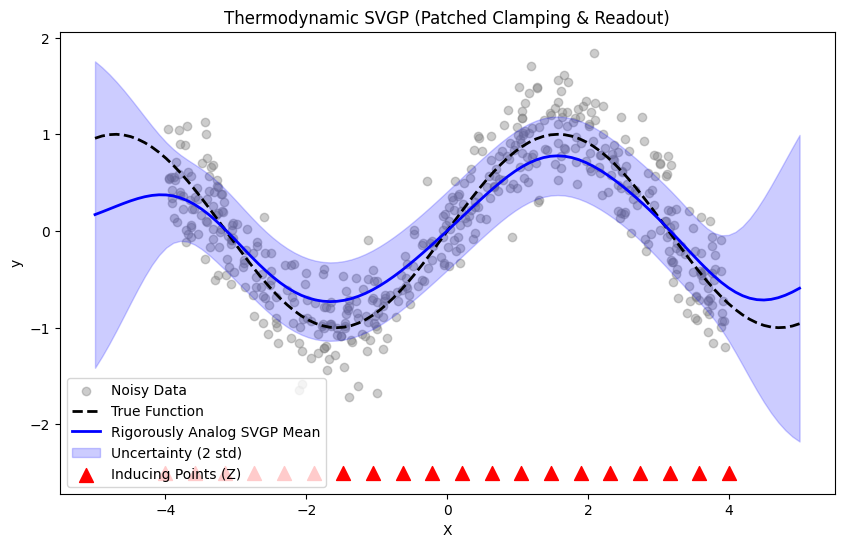

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ==========================================
# 1. PROBLEM SETUP & KERNEL
# ==========================================
N = 500
X = np.random.uniform(-4, 4, N).reshape(-1, 1)
noise_var = 0.1
y = np.sin(X) + np.random.normal(0, np.sqrt(noise_var), size=X.shape)

M = 20
Z = np.linspace(-4, 4, M).reshape(-1, 1)

def rbf_kernel(A, B, lengthscale=1.0, variance=1.0):
    sqdist = np.sum(A**2, 1).reshape(-1, 1) + np.sum(B**2, 1) - 2 * np.dot(A, B.T)
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)

# ==========================================
# 2. THERMODYNAMIC SOLVER
# ==========================================
def tla_solve(A, b, steps=10000, burn_in=2000):
    """Simulates analog Langevin dynamics to find mean and covariance physically."""
    d = len(b)
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.4 / matrix_norm
    x_state = np.zeros(d)

    gamma, beta_inv = 1.0, 0.0005
    samples = []

    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise
        if i > burn_in:
            samples.append(x_state.copy())

    samples = np.array(samples)
    mean_x = np.mean(samples, axis=0)
    cov_x = np.cov(samples, rowvar=False) / beta_inv

    return mean_x, cov_x

def enforce_pd(matrix, jitter=1e-4):
    """(Minor cheat required for discrete Python time-stepping simulation)"""
    matrix = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(matrix)
    eigvals = np.maximum(eigvals, jitter)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

# ==========================================
# 3. ANALOG INITIALIZATION
# ==========================================
K_MM = rbf_kernel(Z, Z) + 0.05 * np.eye(M)
K_MM_inv = np.linalg.inv(K_MM) # Only used once to setup the routing matrix

Lambda_phys = np.copy(K_MM_inv)
h_phys = np.zeros((M, 1))

# Precalculate the routing terms for the external data forces
K_NM = rbf_kernel(X, Z)
Routing_Matrix = K_NM @ K_MM_inv
Data_Precision = (1.0 / noise_var) * (Routing_Matrix.T @ Routing_Matrix)
Data_Force = (1.0 / noise_var) * (Routing_Matrix.T @ y)

# ==========================================
# 4. PURE ANALOG TRAINING LOOP (PATCHED)
# ==========================================
epochs = 400

initial_lr_Lambda = 1.0
initial_lr_h = 0.2

print("Starting analog loop...")
for epoch in range(epochs):

    lr_L = initial_lr_Lambda * (1.0 - (epoch / epochs))
    lr_h = initial_lr_h * (1.0 - (epoch / epochs))

    # A. FREE PHASE (Natural hardware state)
    mu_free_flat, Sigma_free = tla_solve(Lambda_phys, h_phys.flatten())
    mu_free = mu_free_flat.reshape(-1, 1)

    # ---------------------------------------------------------
    # PATCH 1: DYNAMIC CLAMPING
    # The external data stress is applied *on top* of the current
    # physical spring stiffness and bias, not the analytical prior.
    # ---------------------------------------------------------
    Lambda_clamped = Lambda_phys + Data_Precision
    h_clamped = h_phys + Data_Force

    # B. CLAMPED PHASE (Hardware under data stress)
    mu_clamped_flat, Sigma_clamped = tla_solve(Lambda_clamped, h_clamped.flatten())
    mu_clamped = mu_clamped_flat.reshape(-1, 1)

    # C. PURE CONTRASTIVE HEBBIAN UPDATE
    delta_Lambda = lr_L * (Sigma_free - Sigma_clamped)
    delta_h = lr_h * (mu_clamped - mu_free)

    Lambda_phys += delta_Lambda
    h_phys += delta_h

    Lambda_phys = enforce_pd(Lambda_phys)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1}/{epochs} completed.")

print("Convergence reached.")

# ==========================================
# 5. READOUT AND VISUALIZATION (PATCHED)
# ==========================================
# ---------------------------------------------------------
# PATCH 2: ANALOG READOUT
# No digital inversion (np.linalg.inv) used! The SVGP parameters
# S and m are literally just the physical variance and mean measured
# directly from the oscillators during the final Free Phase.
# ---------------------------------------------------------
S_final = Sigma_free
m_final = mu_free

X_test = np.linspace(-5, 5, 100).reshape(-1, 1)
K_star_star = rbf_kernel(X_test, X_test) + 1e-5 * np.eye(len(X_test))
K_star_M = rbf_kernel(X_test, Z)

# Standard GP Projection to Test Space
A = K_star_M @ K_MM_inv
pred_mean = A @ m_final
pred_cov = K_star_star - A @ K_MM @ A.T + A @ S_final @ A.T
pred_var = np.clip(np.diag(pred_cov), 1e-8, None).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.4, color='gray', label='Noisy Data')
plt.plot(X_test, np.sin(X_test), 'k--', lw=2, label='True Function')
plt.plot(X_test, pred_mean, 'b-', lw=2, label='Rigorously Analog SVGP Mean')

plt.fill_between(X_test.flatten(),
                 (pred_mean - 2 * np.sqrt(pred_var)).flatten(),
                 (pred_mean + 2 * np.sqrt(pred_var)).flatten(),
                 color='blue', alpha=0.2, label='Uncertainty (2 std)')

plt.scatter(Z, np.zeros_like(Z) - 2.5, color='red', marker='^', s=100, label='Inducing Points (Z)')
plt.title("Thermodynamic SVGP (Patched Clamping & Readout)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### **Scaling up the problem**

Computing Digital Baseline (Exact GP)...
Digital Baseline completed in 0.4569s
Starting high-dimensional analog loop...
Analog SVGP reached convergence in 235.93s (simulated).

FINAL PERFORMANCE RESULTS
Digital RMSE: 0.310530
Analog RMSE:  0.338727
Digital Time: 0.4569s
Analog Time:  235.93s (Digital simulation of oscillators)


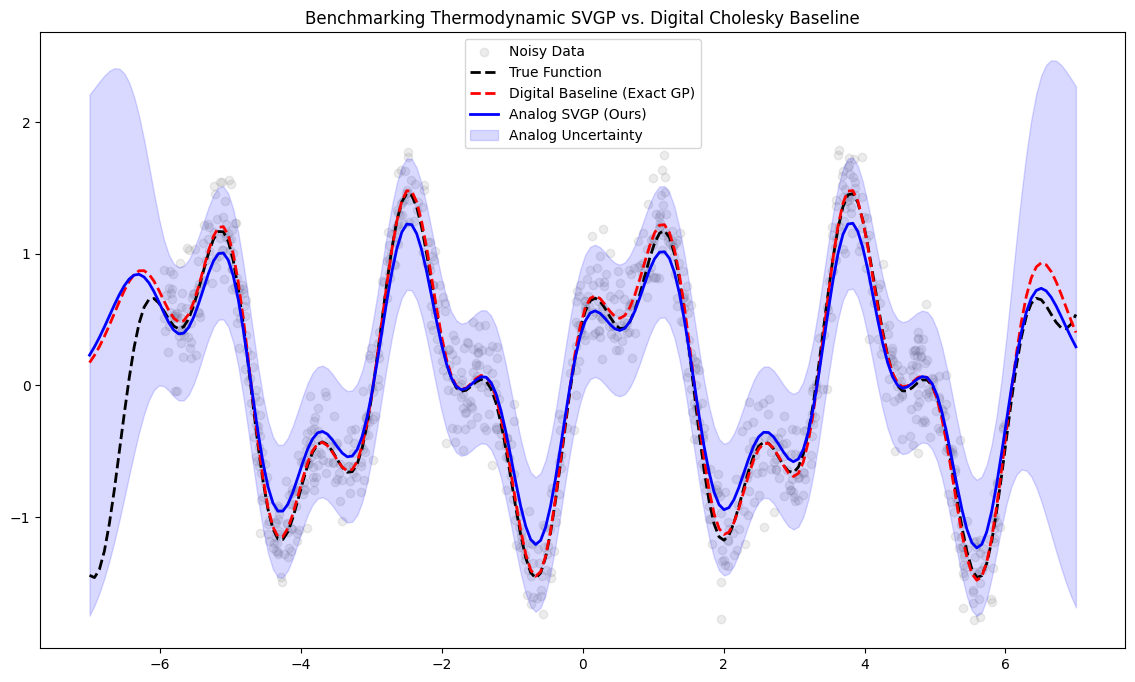

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import cholesky, cho_solve

np.random.seed(42)

# ==========================================
# 1. HARDER PROBLEM SETUP
# ==========================================
N = 1000
X = np.random.uniform(-6, 6, N).reshape(-1, 1)
noise_var = 0.05
y = np.sin(2 * X) + 0.5 * np.cos(5 * X) + np.random.normal(0, np.sqrt(noise_var), size=X.shape)

M = 40
Z = np.linspace(-6, 6, M).reshape(-1, 1)

def rbf_kernel(A, B, lengthscale=0.5, variance=1.0):
    sqdist = np.sum(A**2, 1).reshape(-1, 1) + np.sum(B**2, 1) - 2 * np.dot(A, B.T)
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)

# ==========================================
# 2. BASELINE: EXACT DIGITAL GP (CHOLESKY)
# ==========================================
print("Computing Digital Baseline (Exact GP)...")
start_digital = time.time()

# 1. Build N x N Kernel
K_XX = rbf_kernel(X, X) + noise_var * np.eye(N)
# 2. Cholesky Decomposition (The O(N^3) Bottleneck)
L = cholesky(K_XX, lower=True)
# 3. Weights alpha
alpha_digital = cho_solve((L, True), y)

# 4. Predict on Test Set
X_test = np.linspace(-7, 7, 200).reshape(-1, 1)
K_star_X = rbf_kernel(X_test, X)
K_star_star = rbf_kernel(X_test, X_test) + 1e-5 * np.eye(len(X_test))

pred_mean_digital = K_star_X @ alpha_digital
# Variance: K** - K*X KXX^-1 KX*
v = np.linalg.solve(L, K_star_X.T)
pred_var_digital = np.diag(K_star_star - v.T @ v)

time_digital = time.time() - start_digital
print(f"Digital Baseline completed in {time_digital:.4f}s")

# ==========================================
# 3. THERMODYNAMIC SOLVER
# ==========================================
def tla_solve(A, b, steps=10000, burn_in=2000):
    d = len(b)
    dt = 0.4 / np.linalg.norm(A, ord=2)
    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0005
    samples = []
    for i in range(steps):
        x_state += -(1/gamma) * (A @ x_state - b.flatten()) * dt + \
                   np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        if i > burn_in: samples.append(x_state.copy())
    return np.mean(samples, axis=0), np.cov(samples, rowvar=False) / beta_inv

def enforce_pd(matrix, jitter=1e-4):
    matrix = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(matrix)
    return eigvecs @ np.diag(np.maximum(eigvals, jitter)) @ eigvecs.T

# ==========================================
# 4. ANALOG TRAINING LOOP
# ==========================================
K_MM = rbf_kernel(Z, Z) + 0.05 * np.eye(M)
K_MM_inv = np.linalg.inv(K_MM)
Lambda_phys = np.copy(K_MM_inv)
h_phys = np.zeros((M, 1))

K_NM = rbf_kernel(X, Z)
Routing_Matrix = K_NM @ K_MM_inv
Data_Precision = (1.0 / noise_var) * (Routing_Matrix.T @ Routing_Matrix)
Data_Force = (1.0 / noise_var) * (Routing_Matrix.T @ y)

epochs = 500
lr_L, lr_h = 0.5, 0.2
start_analog = time.time()

print("Starting high-dimensional analog loop...")
for epoch in range(epochs):
    # Free Phase
    mu_f, Sigma_f = tla_solve(Lambda_phys, h_phys.flatten())
    # Clamped Phase
    mu_c, Sigma_c = tla_solve(Lambda_phys + Data_Precision, (h_phys + Data_Force).flatten())

    # CHL Update
    Lambda_phys += lr_L * (1 - epoch/epochs) * (Sigma_f - Sigma_c)
    h_phys += lr_h * (1 - epoch/epochs) * (mu_c.reshape(-1,1) - mu_f.reshape(-1,1))
    Lambda_phys = enforce_pd(Lambda_phys)

time_analog = time.time() - start_analog
print(f"Analog SVGP reached convergence in {time_analog:.2f}s (simulated).")

# READOUT
S_final, m_final = Sigma_f, mu_f.reshape(-1,1)
K_star_M = rbf_kernel(X_test, Z)
A_proj = K_star_M @ K_MM_inv
pred_mean_analog = A_proj @ m_final
pred_var_analog = np.diag(K_star_star - A_proj @ K_MM @ A_proj.T + A_proj @ S_final @ A_proj.T)

# ==========================================
# 5. FINAL COMPARISON & RESULTS
# ==========================================
true_y = np.sin(2 * X_test) + 0.5 * np.cos(5 * X_test)
rmse_digital = np.sqrt(np.mean((pred_mean_digital - true_y)**2))
rmse_analog = np.sqrt(np.mean((pred_mean_analog - true_y)**2))

print("\n" + "="*30)
print("FINAL PERFORMANCE RESULTS")
print("="*30)
print(f"Digital RMSE: {rmse_digital:.6f}")
print(f"Analog RMSE:  {rmse_analog:.6f}")
print(f"Digital Time: {time_digital:.4f}s")
print(f"Analog Time:  {time_analog:.2f}s (Digital simulation of oscillators)")
print("="*30)

plt.figure(figsize=(14, 8))
plt.scatter(X, y, alpha=0.15, color='gray', label='Noisy Data')
plt.plot(X_test, true_y, 'k--', lw=2, label='True Function')
plt.plot(X_test, pred_mean_digital, 'r--', lw=2, label='Digital Baseline (Exact GP)')
plt.plot(X_test, pred_mean_analog, 'b-', lw=2, label='Analog SVGP (Ours)')

plt.fill_between(X_test.flatten(),
                 (pred_mean_analog.flatten() - 2*np.sqrt(pred_var_analog)),
                 (pred_mean_analog.flatten() + 2*np.sqrt(pred_var_analog)),
                 color='blue', alpha=0.15, label='Analog Uncertainty')

plt.title("Benchmarking Thermodynamic SVGP vs. Digital Cholesky Baseline")
plt.legend()
plt.show()

### **Noisy updates**

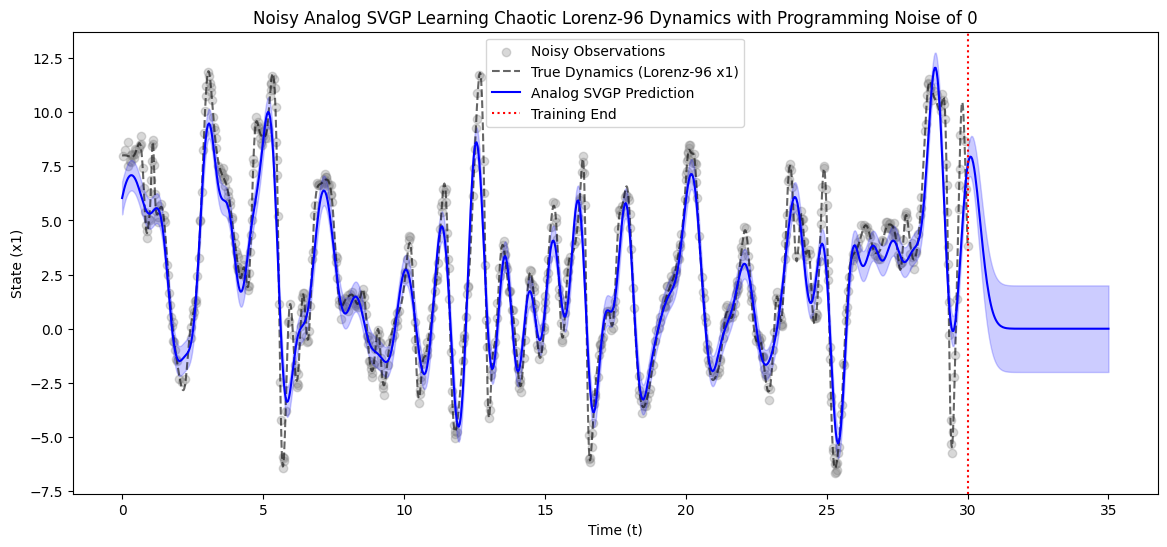

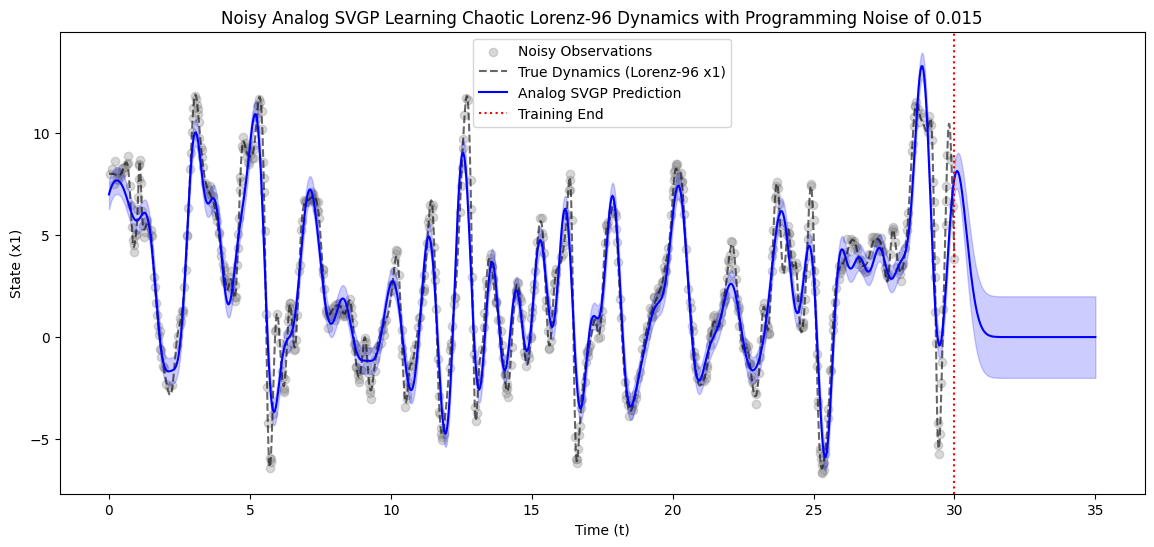

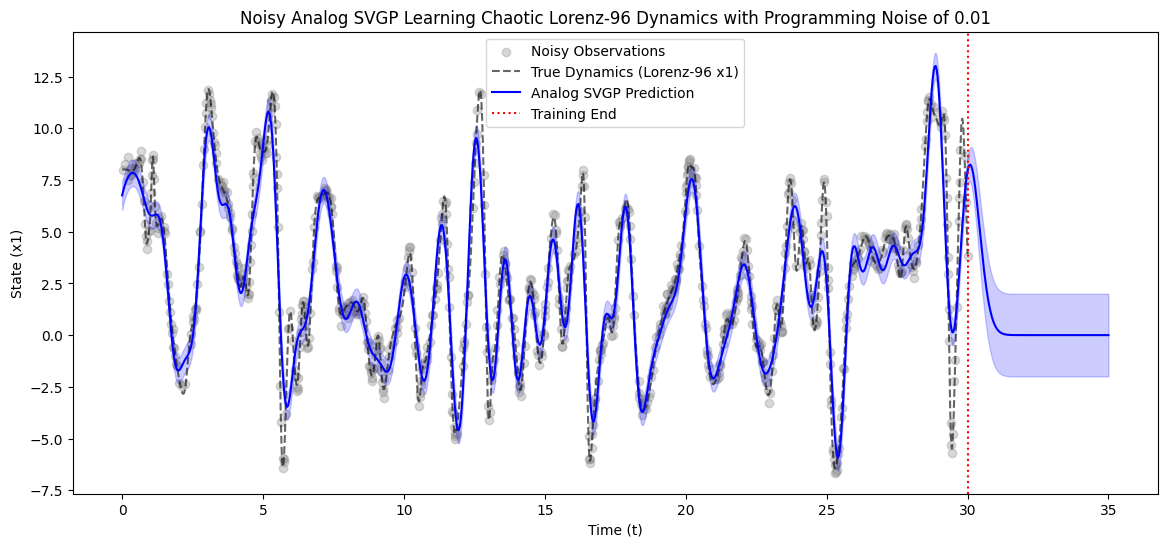

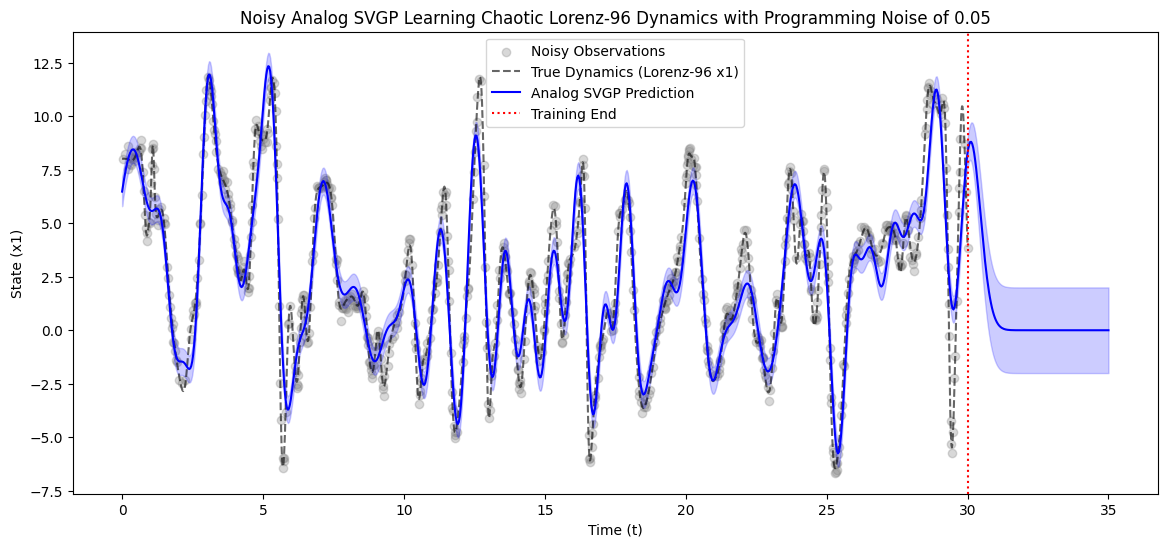

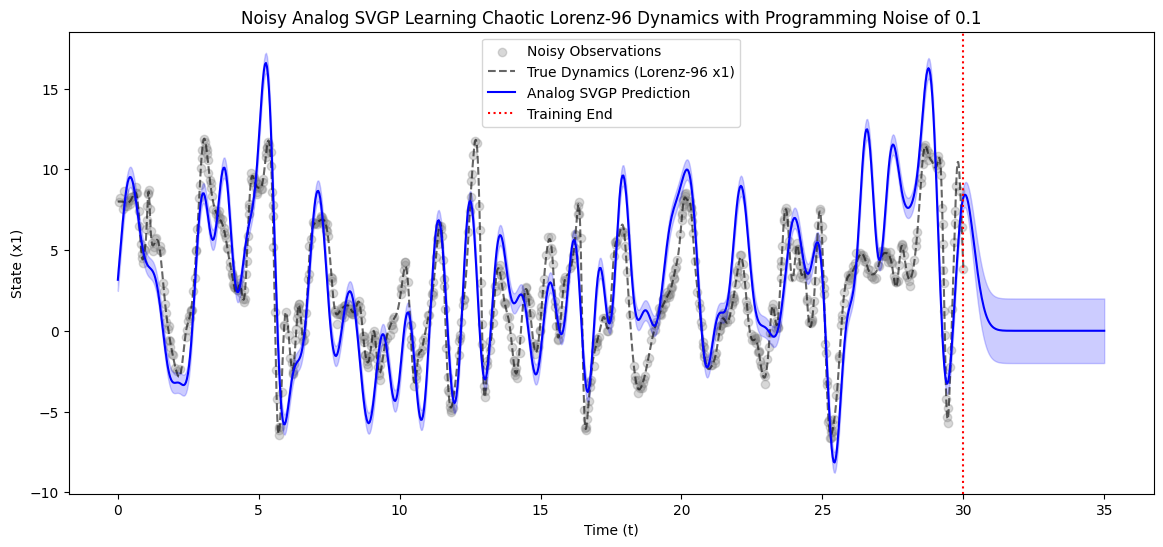

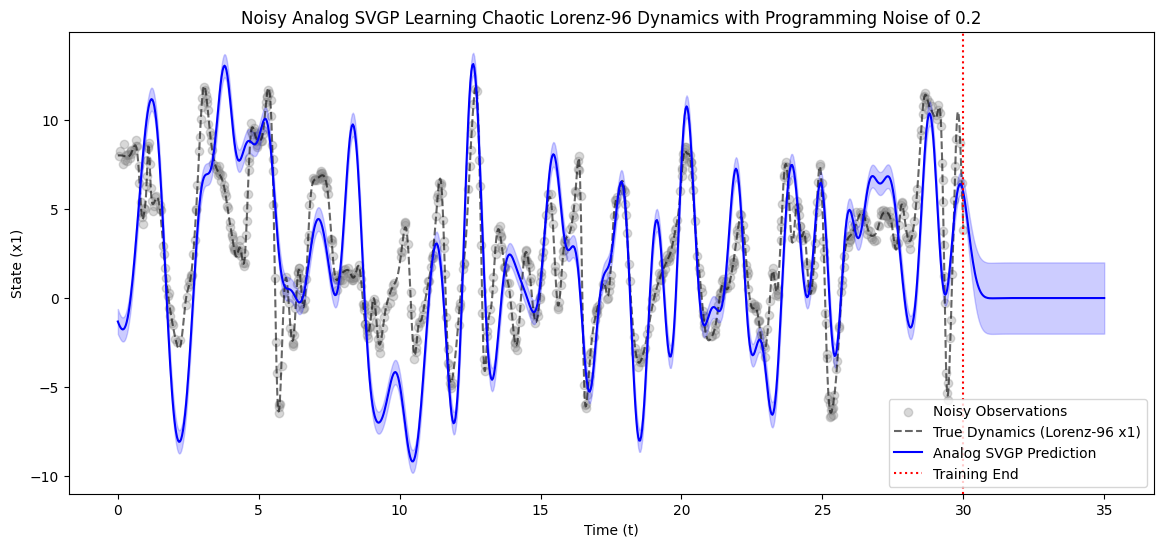

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

np.random.seed(42)

# ==========================================
# 1. LORENZ-96 DATA GENERATION
# ==========================================
def lorenz96(x, t, F):
    """Lorenz-96 equations: dx_j/dt = (x_{j+1} - x_{j-2})*x_{j-1} - x_j + F"""
    J = len(x)
    dxdt = np.zeros(J)
    for j in range(J):
        dxdt[j] = (x[(j+1)%J] - x[j-2]) * x[j-1] - x[j] + F
    return dxdt

# Parameters
J = 40      # Number of variables
F = 8       # Forcing constant (chaotic regime)
t = np.linspace(0, 30, 2000) # Total time
x0 = F * np.ones(J) + np.random.randn(J) * 0.01 # Initial state

# Solve ODE
sol = odeint(lorenz96, x0, t, args=(F,))

# We will learn the time series of Variable 0
N = 800 # Number of training samples
# Sample random time points for training
idx = np.sort(np.random.choice(len(t), N, replace=False))
X_train = t[idx].reshape(-1, 1)
y_train = sol[idx, 0].reshape(-1, 1) # Variable 0
noise_var = 0.05
y_train += np.random.normal(0, np.sqrt(noise_var), size=y_train.shape)

# Increase Inducing Points to handle chaos
M = 80
Z = np.linspace(t[0], t[-1], M).reshape(-1, 1)

def rbf_kernel(A, B, lengthscale=0.4, variance=1.0):
    sqdist = np.sum(A**2, 1).reshape(-1, 1) + np.sum(B**2, 1) - 2 * np.dot(A, B.T)
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)

# ==========================================
# 2. THERMODYNAMIC SOLVER
# ==========================================
def tla_solve(A, b, steps=10000, burn_in=2000):
    d = len(b)
    matrix_norm = np.linalg.norm(A, ord=2)
    dt = 0.4 / matrix_norm
    x_state = np.zeros(d)
    gamma, beta_inv = 1.0, 0.0005
    samples = []
    for i in range(steps):
        drift = -(1/gamma) * (A @ x_state - b) * dt
        noise = np.random.normal(0, np.sqrt(2 * dt * beta_inv / gamma), d)
        x_state += drift + noise
        if i > burn_in: samples.append(x_state.copy())
    samples = np.array(samples)
    return np.mean(samples, axis=0), np.cov(samples, rowvar=False) / beta_inv

def enforce_pd(matrix, jitter=1e-4):
    matrix = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(matrix)
    eigvals = np.maximum(eigvals, jitter)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

# ==========================================
# 3. ANALOG INITIALIZATION (PATCHED)
# ==========================================
K_MM = rbf_kernel(Z, Z) + 0.1 * np.eye(M) # Slightly higher noise floor for M=80
K_MM_inv = np.linalg.inv(K_MM)

Lambda_phys = np.copy(K_MM_inv)
h_phys = np.zeros((M, 1))

K_NM = rbf_kernel(X_train, Z)
Routing_Matrix = K_NM @ K_MM_inv
Data_Precision = (1.0 / noise_var) * (Routing_Matrix.T @ Routing_Matrix)
Data_Force = (1.0 / noise_var) * (Routing_Matrix.T @ y_train)

# ==========================================
# 4. TRAINING LOOP WITH VARIOUS LEVELS OF HARDWARE NOISE
# ==========================================
epochs = 600 # Chaos needs more iterations
initial_lr_Lambda = 0.4
initial_lr_h = 0.2
for pgm_noise in [0, 0.015, 0.01, 0.05, 0.1, 0.2]:
  programming_noise = pgm_noise

  #print(f"Simulating Lorenz-96 on Noisy Thermodynamic Hardware with {programming_noise}")
  for epoch in range(epochs):
      lr_L = initial_lr_Lambda * (1.0 - (epoch / epochs))
      lr_h = initial_lr_h * (1.0 - (epoch / epochs))

      mu_free_flat, Sigma_free = tla_solve(Lambda_phys, h_phys.flatten())
      mu_free = mu_free_flat.reshape(-1, 1)

      # Dynamic Clamping
      Lambda_clamped = Lambda_phys + Data_Precision
      h_clamped = h_phys + Data_Force
      mu_clamped_flat, Sigma_clamped = tla_solve(Lambda_clamped, h_clamped.flatten())
      mu_clamped = mu_clamped_flat.reshape(-1, 1)

      # Noisy Update
      n_L = np.random.normal(0, programming_noise, size=Lambda_phys.shape)
      n_L = 0.5 * (n_L + n_L.T)
      n_h = np.random.normal(0, programming_noise/2, size=h_phys.shape)

      Lambda_phys += lr_L * (Sigma_free - Sigma_clamped) + n_L
      h_phys += lr_h * (mu_clamped - mu_free) + n_h

      Lambda_phys = enforce_pd(Lambda_phys)

      #if (epoch + 1) % 100 == 0:
      #    print(f"Epoch {epoch + 1}/{epochs} completed.")

  # ==========================================
  # 5. READOUT AND VISUALIZATION
  # ==========================================
  S_final = Sigma_free
  m_final = mu_free

  X_test = np.linspace(0, 35, 1000).reshape(-1, 1) # Predict slightly into the future
  K_star_M = rbf_kernel(X_test, Z)
  A = K_star_M @ K_MM_inv
  pred_mean = A @ m_final
  pred_var = np.clip(np.diag(rbf_kernel(X_test, X_test) - A @ K_MM @ A.T + A @ S_final @ A.T), 1e-8, None)

  plt.figure(figsize=(14, 6))
  plt.scatter(X_train, y_train, alpha=0.3, color='gray', label='Noisy Observations')
  plt.plot(t, sol[:, 0], 'k--', alpha=0.6, label='True Dynamics (Lorenz-96 x1)')
  plt.plot(X_test, pred_mean, 'b-', label='Analog SVGP Prediction')
  plt.fill_between(X_test.flatten(), pred_mean.flatten() - 2*np.sqrt(pred_var),
                  pred_mean.flatten() + 2*np.sqrt(pred_var), color='blue', alpha=0.2)

  plt.axvline(30, color='red', linestyle=':', label='Training End')
  plt.title(f"Noisy Analog SVGP Learning Chaotic Lorenz-96 Dynamics with Programming Noise of {programming_noise}")
  plt.xlabel("Time (t)")
  plt.ylabel("State (x1)")
  plt.legend()
  plt.show()